# Blood Pressure Dataset Processing

## Loading Files and Understanding Dataset

In [319]:
# Get current directory
import os
os.getcwd()

'/Users/saadabdullah/Desktop/Data Science/GitHub/Financial-Markets-Analysis'

In [320]:
import pandas as pd

# Define file paths
demo_path = r'/Users/saadabdullah/Downloads/NHANES/DEMO_L.xpt'
bp_path = r'/Users/saadabdullah/Downloads/NHANES/BPXO_L.xpt'
body_path = r'/Users/saadabdullah/Downloads/NHANES/BMX_L.xpt'
diet1_path = r'/Users/saadabdullah/Downloads/NHANES/DR1TOT_L.xpt'
diet2_path = r'/Users/saadabdullah/Downloads/NHANES/DR2TOT_L.xpt'


### NHANES 2021–2023 Complete Demographics Variable List

| Variable Name | Description |
|---------------|-------------|
| DMDBORN4      | Country of birth |
| DMDEDUC2      | Highest grade/degree completed |
| DMDHHSIZ      | Total number of people in household |
| DMDHRAGZ      | Household reference person’s age (years) |
| DMDHREDZ      | Household reference person’s education level |
| DMDHRGND      | Household reference person’s gender |
| DMDHRMAZ      | Household reference person’s marital status |
| DMDHSEDZ      | Household reference person’s spouse’s education level |
| DMDMARTZ      | Marital status |
| DMDYRUSR      | Length of time participant has been in the U.S. |
| DMQMILIZ      | Ever served on active duty in US Armed Forces |
| INDFMPIR      | Ratio of family income to poverty |
| RIAGENDR      | Gender of the participant |
| RIDAGEMN      | Age in months (if ≤24 months old at screening) |
| RIDAGEYR      | Age in years (top-coded at 80+ years) |
| RIDEXAGM      | Age in months (if ≤19 years old at exam) |
| RIDEXMON      | Six-month period of examination (Nov–Apr / May–Oct) |
| RIDEXPRG      | Pregnancy status (females aged 20–44 at exam) |
| RIDRETH1      | Recode of reported race & Hispanic origin |
| RIDRETH3      | Recode of race & Hispanic origin, including Non-Hispanic Asian |
| RIDSTATR      | Interview/examination status |
| SDDSRVYR      | Data release cycle |
| SDMVPSU       | Masked pseudo-PSU (variance estimation) |
| SDMVSTRA      | Masked pseudo-stratum (variance estimation) |
| SEQN          | Respondent sequence number |
| WTINT2YR      | Full-sample 2-year interview weight |
| WTMEC2YR      | Full-sample 2-year MEC exam weight |


In [321]:
demo_df = pd.read_sas(demo_path)
demo_df.shape

(11933, 27)

### NHANES 2021–2023 Complete Examination Variables

| Domain       | Variable Name | Description                                               |
|--------------|---------------|-----------------------------------------------------------|
| **Body Measures** | BMXARMC      | Arm circumference (cm)                                     |
|              | BMXARML      | Upper arm length (cm)                                     |
|              | BMXBMI       | Body Mass Index (kg/m²)                                   |
|              | BMXHEAD      | Head circumference (cm)                                   |
|              | BMXHIP       | Hip circumference (cm)                                    |
|              | BMXHT        | Standing height (cm)                                      |
|              | BMXLEG       | Upper leg length (cm)                                     |
|              | BMXRECUM     | Recumbent length (cm)                                     |
|              | BMXWAIST     | Waist circumference (cm)                                  |
|              | BMXWT        | Weight (kg)                                               |
|              | BMDBMIC      | BMI category (children/youth)                             |
|              | BMDSTATS     | Body Measures component status code                       |
|              | *Other comment vars…* | *Comment variables for quality/notes*            |
| **Blood Pressure (Oscillometric)** | BPXOSY1      | Systolic – 1st oscillometric reading                 |
|              | BPXOSY2      | Systolic – 2nd oscillometric reading                 |
|              | BPXOSY3      | Systolic – 3rd oscillometric reading                 |
|              | BPXODI1      | Diastolic – 1st oscillometric reading                |
|              | BPXODI2      | Diastolic – 2nd oscillometric reading                |
|              | BPXODI3      | Diastolic – 3rd oscillometric reading                |
|              | BPXOPLS1     | Pulse – 1st oscillometric reading                     |
|              | BPXOPLS2     | Pulse – 2nd oscillometric reading                     |
|              | BPXOPLS3     | Pulse – 3rd oscillometric reading                     |
|              | BPAOARM      | Arm selected for BP measurement                        |
|              | BPAOCSZ      | Mid-arm circumference for cuff sizing (cm)             |


In [322]:
bp_df = pd.read_sas(bp_path)
body_df = pd.read_sas(body_path)
print(bp_df.shape)
print(body_df.shape)

(7801, 12)
(8860, 22)


### NHANES 2021–2023 Filtered Nutrition Intake Variables

Filtered to only take relevant nutrients

In [323]:
# Day 1
diet1_df = pd.read_sas(diet1_path)

# Day 2
diet2_df = pd.read_sas(diet2_path)

print(diet1_df.shape)
print(diet2_df.shape)


(8860, 168)
(8860, 85)


### Dataset

#### Since the primary goal of this experiment is to understand different factors on **blood pressure**, the dataset was filtered to only include individuals that have blood pressure data.

Total participants included in this study: 7801


## NHANES 2021–2023 Blood Pressure Study — Data Dictionary

This table lists the **demographics, body measures, and blood pressure variables** for Phase 1 of the study. Phase 2 dietary variables are indicated as placeholders.

---

### 1. Demographics (DEMO_L)

| Variable Name | Description | Notes / Purpose |
|---------------|-------------|----------------|
| SEQN          | Respondent sequence number | Merge key across datasets |
| RIDAGEYR      | Age in years | Major BP determinant |
| RIAGENDR      | Gender | Sex differences in BP |
| RIDRETH1      | Race/Hispanic origin | BP differences by race/ethnicity |
| DMDEDUC2      | Education level | Socioeconomic status proxy |
| INDFMPIR      | Family income to poverty ratio | SES / confounder |
| DMDMARTZ      | Marital status | Social determinant |
| RIDEXMON      | Exam month | Capture seasonal BP effects |

---

### 2. Body Measures (BMX_L)

| Variable Name | Description | Notes / Purpose |
|---------------|-------------|----------------|
| BMXWT          | Weight (kg) | BMI, obesity adjustment |
| BMXHT          | Standing height (cm) | BMI calculation |
| BMXBMI         | Body Mass Index (kg/m²) | Primary adiposity measure |
| BMXWAIST       | Waist circumference (cm) | Central adiposity / cardiometabolic risk |
| BMXHIP         | Hip circumference (cm) | Optional: waist-to-hip ratio |
| BMXARMC        | Upper arm circumference (cm) | Optional body composition proxy |
| BMXLEG         | Upper leg length (cm) | Optional body composition proxy |
| BMXHEAD        | Head circumference (cm) | Usually optional (children only) |
| BMXRECUM       | Recumbent length (cm) | Infants/toddlers; usually not needed for adult BP study |

> **Tip:** Focus on **BMXWT, BMXHT, BMXBMI, BMXWAIST** for adults.

---

### 3. Blood Pressure (Oscillometric, BPX_L)

| Variable Name | Description | Notes / Purpose |
|---------------|-------------|----------------|
| BPXOSY1       | Systolic BP, 1st reading | Compute mean SBP |
| BPXOSY2       | Systolic BP, 2nd reading | Compute mean SBP |
| BPXOSY3       | Systolic BP, 3rd reading | Compute mean SBP |
| BPXODI1       | Diastolic BP, 1st reading | Compute mean DBP |
| BPXODI2       | Diastolic BP, 2nd reading | Compute mean DBP |
| BPXODI3       | Diastolic BP, 3rd reading | Compute mean DBP |
| BPAOARM       | Arm selected for BP measurement | Optional, quality check |
| BPAOCSZ       | Mid-arm circumference for cuff sizing | Optional, quality check |

> **Tip:** Average the 3 readings for SBP and DBP for modeling.

---

### 4. Survey Design / Weights

| Variable Name | Description | Notes / Purpose |
|---------------|-------------|----------------|
| WTMEC2YR      | MEC exam weight | Required for survey-weighted analysis |
| SDMVPSU       | Pseudo-PSU | Survey design, variance estimation |
| SDMVSTRA      | Pseudo-stratum | Survey design, variance estimation |

---

### 5. Phase 2 Dietary Variables (Placeholders)

| Variable Name | Description | Notes / Purpose |
|---------------|-------------|----------------|
| DR1TSODI      | Sodium intake, Day 1 (mg) | Key nutrient affecting BP |
| DR1TPOTA      | Potassium intake, Day 1 (mg) | Key nutrient affecting BP |
| DR1TMAGN      | Magnesium intake, Day 1 (mg) | Key nutrient affecting BP |
| DR1TCALC      | Calcium intake, Day 1 (mg) | Key nutrient affecting BP |
| DR1TKCAL      | Energy intake, Day 1 (kcal) | Energy adjustment |
| DR1TALCO      | Alcohol intake, Day 1 (g) | Confounder |
| DR1TCAFF      | Caffeine intake, Day 1 (mg) | Confounder |
| DR2TSODI      | Sodium intake, Day 2 (mg) | Optional: day-to-day variation |
| DR2TPOTA      | Potassium intake, Day 2 (mg) | Optional |
| DR2TMAGN      | Magnesium intake, Day 1 (mg) | Optional |
| DR2TCALC      | Calcium intake, Day 1 (mg) | Optional |
| DR2TKCAL      | Energy intake, Day 2 (kcal) | Optional |
| DR2TALCO      | Alcohol intake, Day 2 (g) | Optional |
| DR2TCAFF      | Caffeine intake, Day 2 (mg) | Optional |

> **Tip:** Use Day 1 for Phase 2 models; include Day 2 if estimating usual intake or reducing within-person variability.

---

**Workflow Note:**  
1. Phase 1: Analyze demographics + body measures + BP.  
2. Phase 2: Merge dietary variables using `SEQN` and apply proper **dietary survey weights** (`WTDRD1` or `WTDR2D`) with `SDMVPSU` and `SDMVSTRA`.  
3. Always document variable sources, transformations (e.g., averaging BP readings), and inclusion/exclusion criteria.


## Data Cleaning and Imputations

### Select Relevant Columns

In [324]:
# --- 1. Select relevant columns ---

# Demographics
demo_cols = [
    'SEQN',       # Merge key
    'RIDAGEYR',   # Age
    'RIAGENDR',   # Gender
    'RIDRETH1',   # Race/Hispanic
    'DMDEDUC2',   # Education
    'INDFMPIR',   # Income/poverty ratio
    'DMDMARTZ',   # Marital status
    'WTMEC2YR',   # Exam sample weight
    'SDMVSTRA',   # Stratum for survey design
    'SDMVPSU'     # PSU for survey design
]
demo_df_filtered = demo_df[demo_cols]

# Body Measures
body_cols = [
    'SEQN',       # Merge key
    'BMXWT',      # Weight (kg)
    'BMXHT',      # Standing height (cm)
    'BMXBMI'     # BMI
]
body_df_filtered = body_df[body_cols]

# Blood Pressure
bp_cols = [
    'SEQN',       # Merge key
    'BPXOSY1', 'BPXOSY2', 'BPXOSY3',   # Systolic readings
    'BPXODI1', 'BPXODI2', 'BPXODI3',   # Diastolic readings
    'BPAOCSZ'     # Mid-arm circumference for cuff
]
bp_df_filtered = bp_df[bp_cols]

# Nutrition Intake
bp_related_cols1 = [
    "SEQN",
    "DR1TSODI",  # Sodium intake, Day 1 (mg)
    "DR1TPOTA",  # Potassium intake, Day 1 (mg)
    "DR1TMAGN",  # Magnesium intake, Day 1 (mg)
    "DR1TCALC",  # Calcium intake, Day 1 (mg)
    "DR1TKCAL",  # Energy intake, Day 1 (kcal)
    "DR1TALCO",  # Alcohol intake, Day 1 (g)
    "DR1TCAFF"   # Caffeine intake, Day 1 (mg)
]

bp_related_cols2 = [
    "SEQN",
    "DR2TSODI",  # Sodium intake, Day 1 (mg)
    "DR2TPOTA",  # Potassium intake, Day 1 (mg)
    "DR2TMAGN",  # Magnesium intake, Day 1 (mg)
    "DR2TCALC",  # Calcium intake, Day 1 (mg)
    "DR2TKCAL",  # Energy intake, Day 1 (kcal)
    "DR2TALCO",  # Alcohol intake, Day 1 (g)
    "DR2TCAFF"   # Caffeine intake, Day 1 (mg)
]
diet1_df_filtered = diet1_df[bp_related_cols1]
diet2_df_filtered = diet2_df[bp_related_cols2]

# --- 2. Merge the dataframes ---

# Merge stepwise: demo + body, then + BP
merged_df = bp_df_filtered.merge(body_df_filtered, on='SEQN', how='inner') \
                            .merge(demo_df_filtered, on='SEQN', how='inner') \
                            .merge(diet1_df_filtered, on='SEQN', how='inner') \
                            .merge(diet2_df_filtered, on='SEQN', how='inner')


# --- 3. Check merged dataframe ---
print(f"Merged dataframe shape: {merged_df.shape}")


Merged dataframe shape: (7801, 34)


In [325]:
merged_df.head()

,SEQN,BPXOSY1,BPXOSY2,BPXOSY3,BPXODI1,BPXODI2,BPXODI3,BPAOCSZ,BMXWT,BMXHT,...,DR1TKCAL,DR1TALCO,DR1TCAFF,DR2TSODI,DR2TPOTA,DR2TMAGN,DR2TCALC,DR2TKCAL,DR2TALCO,DR2TCAFF
0,130378.0,135.0,131.0,132.0,98.0,96.0,94.0,4.0,86.9,179.5,...,1740.0,3.420000e+01,242.0,1660.0,1861.0,212.0,166.0,1040.0,1.140000e+01,79.0
1,130379.0,121.0,117.0,113.0,84.0,76.0,76.0,4.0,101.8,174.2,...,2741.0,8.030000e+01,10.0,3438.0,3560.0,403.0,779.0,2228.0,4.030000e+01,4.0
2,130380.0,111.0,112.0,104.0,79.0,80.0,76.0,4.0,69.4,152.9,...,1995.0,5.397605e-79,51.0,2979.0,1991.0,315.0,418.0,1475.0,5.397605e-79,103.0
3,130386.0,110.0,120.0,115.0,72.0,74.0,75.0,4.0,90.6,173.3,...,2422.0,5.397605e-79,192.0,2905.0,1302.0,126.0,373.0,1844.0,1.860000e+01,288.0
4,130387.0,143.0,136.0,145.0,76.0,74.0,78.0,4.0,103.5,155.9,...,3849.0,5.397605e-79,100.0,7901.0,5386.0,372.0,702.0,3156.0,5.397605e-79,87.0


### Calculate Means and Remove Unnecessary Columns

In [326]:
# Create mean columns for blood pressure
merged_df['sbp_mean'] = merged_df[['BPXOSY1','BPXOSY2','BPXOSY3']].mean(axis=1, skipna=True)
merged_df['dbp_mean'] = merged_df[['BPXODI1','BPXODI2','BPXODI3']].mean(axis=1, skipna=True)

# Drop the individual readings 
bp_reading_cols = ['BPXOSY1','BPXOSY2','BPXOSY3',
                   'BPXODI1','BPXODI2','BPXODI3']
merged_df.drop(columns=bp_reading_cols, inplace=True)

# Create mean columns for each nutrient across Day 1 and Day 2
merged_df['sodium_mean'] = merged_df[['DR1TSODI', 'DR2TSODI']].mean(axis=1, skipna=True)
merged_df['potassium_mean'] = merged_df[['DR1TPOTA', 'DR2TPOTA']].mean(axis=1, skipna=True)
merged_df['magnesium_mean'] = merged_df[['DR1TMAGN', 'DR2TMAGN']].mean(axis=1, skipna=True)
merged_df['calcium_mean'] = merged_df[['DR1TCALC', 'DR2TCALC']].mean(axis=1, skipna=True)
merged_df['energy_mean'] = merged_df[['DR1TKCAL', 'DR2TKCAL']].mean(axis=1, skipna=True)
merged_df['alcohol_mean'] = merged_df[['DR1TALCO', 'DR2TALCO']].mean(axis=1, skipna=True)
merged_df['caffeine_mean'] = merged_df[['DR1TCAFF', 'DR2TCAFF']].mean(axis=1, skipna=True)

# Drop the individual Day 1 / Day 2 nutrient readings
nutrient_day_cols = [
    'DR1TSODI', 'DR2TSODI',  # Sodium
    'DR1TPOTA', 'DR2TPOTA',  # Potassium
    'DR1TMAGN', 'DR2TMAGN',  # Magnesium
    'DR1TCALC', 'DR2TCALC',  # Calcium
    'DR1TKCAL', 'DR2TKCAL',  # Energy
    'DR1TALCO', 'DR2TALCO',  # Alcohol
    'DR1TCAFF', 'DR2TCAFF'   # Caffeine
]
merged_df.drop(columns=nutrient_day_cols, inplace=True)


In [327]:
merged_df.shape

(7801, 23)

In [328]:
# Rename dictionary: old column -> new readable name
rename_dict = {
    # Demographics
    'SEQN': 'participant_id',
    'RIDAGEYR': 'age',
    'RIAGENDR': 'gender',
    'RIDRETH1': 'race_ethnicity',
    'DMDEDUC2': 'education_level',
    'INDFMPIR': 'income_poverty_ratio',
    'DMDMARTZ': 'marital_status',
    'WTMEC2YR': 'mec_exam_weight',
    'SDMVSTRA': 'survey_stratum',
    'SDMVPSU': 'survey_psu',
    
    # Body measures
    'BMXWT': 'weight_kg',
    'BMXHT': 'height_cm',
    'BMXBMI': 'bmi',
    
    # Blood pressure
    'BPAOCSZ': 'bp_cuff_size'
}


# Apply renaming
merged_df.rename(columns=rename_dict, inplace=True)

# Quick check
print(merged_df.head())


   participant_id  bp_cuff_size  weight_kg  height_cm   bmi   age  gender  \
0        130378.0           4.0       86.9      179.5  27.0  43.0     1.0   
1        130379.0           4.0      101.8      174.2  33.5  66.0     1.0   
2        130380.0           4.0       69.4      152.9  29.7  44.0     2.0   
3        130386.0           4.0       90.6      173.3  30.2  34.0     1.0   
4        130387.0           4.0      103.5      155.9  42.6  68.0     2.0   

   race_ethnicity  education_level  income_poverty_ratio  ...  survey_psu  \
0             5.0              5.0                  5.00  ...         2.0   
1             3.0              5.0                  5.00  ...         2.0   
2             2.0              3.0                  1.41  ...         1.0   
3             1.0              4.0                  1.33  ...         1.0   
4             3.0              5.0                  1.32  ...         1.0   

     sbp_mean   dbp_mean  sodium_mean  potassium_mean  magnesium_mean  \
0

### Check for Missing Values 

In [329]:
merged_df.isna().sum()

participant_id             0
bp_cuff_size             190
weight_kg                 95
height_cm                 82
bmi                      110
age                        0
gender                     0
race_ethnicity             0
education_level         1737
income_poverty_ratio    1000
marital_status          1738
mec_exam_weight            0
survey_stratum             0
survey_psu                 0
sbp_mean                 283
dbp_mean                 283
sodium_mean             1830
potassium_mean          1830
magnesium_mean          1830
calcium_mean            1830
energy_mean             1830
alcohol_mean            1830
caffeine_mean           1830
dtype: int64

In [330]:
# Drop rows where SBP or DBP mean could not be computed (all readings missing)
merged_df = merged_df.dropna(subset=['sbp_mean','dbp_mean','bmi'])

# Convert missing or unreported values ot Nan ---
merged_df['education_level'] = merged_df['education_level'].replace(9.0, pd.NA)
merged_df['marital_status'] = merged_df['marital_status'].replace(99.0, pd.NA)
merged_df['marital_status'] = merged_df['marital_status'].replace(77.0, pd.NA)

In [331]:
merged_df.isna().sum()

participant_id             0
bp_cuff_size               0
weight_kg                  0
height_cm                  0
bmi                        0
age                        0
gender                     0
race_ethnicity             0
education_level         1650
income_poverty_ratio     939
marital_status          1653
mec_exam_weight            0
survey_stratum             0
survey_psu                 0
sbp_mean                   0
dbp_mean                   0
sodium_mean             1674
potassium_mean          1674
magnesium_mean          1674
calcium_mean            1674
energy_mean             1674
alcohol_mean            1674
caffeine_mean           1674
dtype: int64

### Check Correlations of Total Nutrition for Imputation

In [333]:
import pandas as pd

nutrient_cols = ['sodium_mean','potassium_mean','magnesium_mean','calcium_mean',
                 'energy_mean','alcohol_mean','caffeine_mean']

# Only numeric columns for correlation check
num_cols = merged_df.select_dtypes(include=['number'])

# Correlation of each nutrient with all other numeric variables
for nutrient in nutrient_cols:
    print(f"\nTop correlations for {nutrient}:")
    corr_series = num_cols.corr()[nutrient].abs().sort_values(ascending=False)
    print(corr_series.head(8))  # Show top 8 correlations


Top correlations for sodium_mean:
sodium_mean       1.000000
energy_mean       0.817971
potassium_mean    0.640466
magnesium_mean    0.565745
calcium_mean      0.552991
gender            0.278435
height_cm         0.272237
caffeine_mean     0.141813
Name: sodium_mean, dtype: float64

Top correlations for potassium_mean:
potassium_mean    1.000000
magnesium_mean    0.827964
energy_mean       0.716144
sodium_mean       0.640466
calcium_mean      0.592072
caffeine_mean     0.269375
height_cm         0.264121
gender            0.232855
Name: potassium_mean, dtype: float64

Top correlations for magnesium_mean:
magnesium_mean    1.000000
potassium_mean    0.827964
energy_mean       0.689443
calcium_mean      0.616595
sodium_mean       0.565745
height_cm         0.268431
caffeine_mean     0.228050
gender            0.217440
Name: magnesium_mean, dtype: float64

Top correlations for calcium_mean:
calcium_mean       1.000000
energy_mean        0.638975
magnesium_mean     0.616595
potassium_mea

#### Findings
Sodium, potassium, magnesium, calcium, and energy are highly correlated with each other (0.55–0.83 range).

    → This means missing sodium could be predicted very well using energy intake plus the other nutrients.

Alcohol has weak correlations with nutrients — much more tied to lifestyle/demographics than diet volume.

    → Use energy intake, gender, height, BP as predictors.

Caffeine is weakly correlated with other nutrients, but more with age.

    → Use age, weight, height, energy intake as predictors.

In [334]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
import pandas as pd

# Define predictors per nutrient correlation results
predictors_map = {
    'sodium_mean':     ['energy_mean', 'potassium_mean', 'magnesium_mean', 'calcium_mean', 'gender', 'height_cm', 'caffeine_mean'],
    'potassium_mean':  ['magnesium_mean', 'energy_mean', 'sodium_mean', 'calcium_mean', 'caffeine_mean', 'height_cm', 'gender'],
    'magnesium_mean':  ['potassium_mean', 'energy_mean', 'calcium_mean', 'sodium_mean', 'height_cm', 'caffeine_mean', 'gender'],
    'calcium_mean':    ['energy_mean', 'magnesium_mean', 'potassium_mean', 'sodium_mean', 'gender', 'height_cm'],
    'energy_mean':     ['sodium_mean', 'potassium_mean', 'magnesium_mean', 'calcium_mean', 'gender', 'height_cm', 'alcohol_mean'],
    'alcohol_mean':    ['energy_mean', 'height_cm', 'magnesium_mean', 'gender', 'dbp_mean', 'potassium_mean', 'sbp_mean'],
    'caffeine_mean':   ['age', 'potassium_mean', 'magnesium_mean', 'height_cm', 'energy_mean', 'weight_kg', 'sodium_mean']
}

# Impute each nutrient separately
for nutrient, predictors in predictors_map.items():
    cols_to_impute = [nutrient] + predictors
    imputer = IterativeImputer(random_state=42)
    merged_df[cols_to_impute] = imputer.fit_transform(merged_df[cols_to_impute])


### Impute Income/Poverty Ratio Using Education Level 

In [336]:
merged_df.isna().sum()

participant_id             0
bp_cuff_size               0
weight_kg                  0
height_cm                  0
bmi                        0
age                        0
gender                     0
race_ethnicity             0
education_level         1650
income_poverty_ratio     939
marital_status          1653
mec_exam_weight            0
survey_stratum             0
survey_psu                 0
sbp_mean                   0
dbp_mean                   0
sodium_mean                0
potassium_mean             0
magnesium_mean             0
calcium_mean               0
energy_mean                0
alcohol_mean               0
caffeine_mean              0
dtype: int64

In [337]:
numeric_cols = merged_df.select_dtypes(include=['number']).columns
corr_matrix = merged_df[numeric_cols].corr()

income_corr = corr_matrix['income_poverty_ratio'].sort_values(ascending=False)
print("Top correlations with income_poverty_ratio:\n", income_corr.head(15))

Top correlations with income_poverty_ratio:
 income_poverty_ratio    1.000000
education_level         0.492935
magnesium_mean          0.194259
potassium_mean          0.181094
height_cm               0.174310
age                     0.145396
caffeine_mean           0.132886
mec_exam_weight         0.129158
sodium_mean             0.111410
energy_mean             0.105051
calcium_mean            0.091642
alcohol_mean            0.083755
survey_psu              0.060808
weight_kg               0.054527
race_ethnicity          0.044534
Name: income_poverty_ratio, dtype: float64


In [338]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
import pandas as pd

predictors = ['education_level'] # Add more numeric predictors if desired
cols_to_impute = ['income_poverty_ratio'] + predictors
df_subset = merged_df[cols_to_impute].copy()
imputer = IterativeImputer(max_iter=10, random_state=42)
# Fit-transform only the income_poverty_ratio (education_level stays as is for non-missing)
df_subset_imputed = imputer.fit_transform(df_subset)
# Put the imputed income_poverty_ratio back in the original dataframe
merged_df['income_poverty_ratio'] = df_subset_imputed[:, 0]


In [339]:
merged_df.isna().sum()

participant_id             0
bp_cuff_size               0
weight_kg                  0
height_cm                  0
bmi                        0
age                        0
gender                     0
race_ethnicity             0
education_level         1650
income_poverty_ratio       0
marital_status          1653
mec_exam_weight            0
survey_stratum             0
survey_psu                 0
sbp_mean                   0
dbp_mean                   0
sodium_mean                0
potassium_mean             0
magnesium_mean             0
calcium_mean               0
energy_mean                0
alcohol_mean               0
caffeine_mean              0
dtype: int64

In [340]:
print(merged_df['education_level'].value_counts())

5.0    2077
4.0    1769
3.0    1232
2.0     452
1.0     273
Name: education_level, dtype: int64


### Check Correlation for Education Imputation

In [342]:
import pandas as pd


numeric_cols = merged_df.select_dtypes(include=['number']).columns

corr_matrix = merged_df[numeric_cols].corr()
edu_corr = corr_matrix['education_level'].sort_values(ascending=False)
print("Top correlations with education_level:\n", edu_corr.head(10))

Top correlations with education_level:
 education_level         1.000000
income_poverty_ratio    0.539268
magnesium_mean          0.182145
potassium_mean          0.159297
height_cm               0.153634
race_ethnicity          0.124422
calcium_mean            0.115501
sodium_mean             0.108727
energy_mean             0.098503
caffeine_mean           0.078840
Name: education_level, dtype: float64


In [345]:
# Step 1: Create grouping variable from income_poverty_ratio
merged_df['income_group'] = merged_df['income_poverty_ratio'].round(1)

# Step 2: Fill missing education_level with median within each income_group
merged_df['education_level'] = merged_df.groupby('income_group')['education_level'] \
                                       .transform(lambda x: x.fillna(round(x.median())))

# Optional: Drop the temporary grouping column
merged_df.drop(columns=['income_group'], inplace=True)

# Verify
print(merged_df['education_level'].isna().sum())


0


### Check for Unreported Values

In [347]:
print(merged_df['gender'].value_counts())
print(merged_df['race_ethnicity'].value_counts())
print(merged_df['education_level'].value_counts())
print(merged_df['marital_status'].value_counts())


2.0    4007
1.0    3446
Name: gender, dtype: int64
3.0    4100
5.0     958
4.0     926
2.0     823
1.0     646
Name: race_ethnicity, dtype: int64
4.0    2619
5.0    2349
3.0    1691
2.0     497
1.0     297
Name: education_level, dtype: int64
1.0    3178
2.0    1441
3.0    1181
Name: marital_status, dtype: int64


In [348]:
print(merged_df.isna().sum())
print(merged_df.shape)

participant_id             0
bp_cuff_size               0
weight_kg                  0
height_cm                  0
bmi                        0
age                        0
gender                     0
race_ethnicity             0
education_level            0
income_poverty_ratio       0
marital_status          1653
mec_exam_weight            0
survey_stratum             0
survey_psu                 0
sbp_mean                   0
dbp_mean                   0
sodium_mean                0
potassium_mean             0
magnesium_mean             0
calcium_mean               0
energy_mean                0
alcohol_mean               0
caffeine_mean              0
dtype: int64
(7453, 23)


## Data Transformation and Feature Engineering

In [349]:
merged_df.head()

,participant_id,bp_cuff_size,weight_kg,height_cm,bmi,age,gender,race_ethnicity,education_level,income_poverty_ratio,...,survey_psu,sbp_mean,dbp_mean,sodium_mean,potassium_mean,magnesium_mean,calcium_mean,energy_mean,alcohol_mean,caffeine_mean
0,130378.0,4.0,86.9,179.5,27.0,43.0,1.0,5.0,5.0,5.00,...,2.0,132.666667,96.000000,2144.0,1889.0,208.0,429.5,1390.0,2.280000e+01,160.5
1,130379.0,4.0,101.8,174.2,33.5,66.0,1.0,3.0,5.0,5.00,...,2.0,117.000000,78.666667,4536.5,4515.0,508.5,726.5,2484.5,6.030000e+01,7.0
2,130380.0,4.0,69.4,152.9,29.7,44.0,2.0,2.0,3.0,1.41,...,1.0,109.000000,78.333333,2934.5,2053.5,353.0,988.5,1735.0,5.397605e-79,77.0
3,130386.0,4.0,90.6,173.3,30.2,34.0,1.0,1.0,4.0,1.33,...,1.0,115.000000,73.666667,3520.5,1991.0,209.0,636.5,2133.0,9.300000e+00,240.0
4,130387.0,4.0,103.5,155.9,42.6,68.0,2.0,3.0,5.0,1.32,...,1.0,141.333333,76.000000,7097.5,4593.0,315.5,605.0,3502.5,5.397605e-79,93.5


In [350]:
df = merged_df

### Transform Categorial Variables
 

In [351]:
# Gender
gender_mapping = {
    1: 'Male',
    2: 'Female'
}
df['gender'] = df['gender'].replace(gender_mapping).astype('category')

# Race/Ethnicity
race_mapping = {
    1: 'Mexican American',
    2: 'Other Hispanic',
    3: 'Non-Hispanic White',
    4: 'Non-Hispanic Black',
    5: 'Other Race - Including Multi-Racial'
}
df['race_ethnicity'] = df['race_ethnicity'].replace(race_mapping).astype('category')

# Marital Status
marital_mapping = {
    None: 'Missing',
    1: 'Married',
    2: 'Widowed/Divorced/Separated',
    3: 'Never married/Single'
}
df['marital_status'] = df['marital_status'].replace(marital_mapping).astype('category')

df.head()


,participant_id,bp_cuff_size,weight_kg,height_cm,bmi,age,gender,race_ethnicity,education_level,income_poverty_ratio,...,survey_psu,sbp_mean,dbp_mean,sodium_mean,potassium_mean,magnesium_mean,calcium_mean,energy_mean,alcohol_mean,caffeine_mean
0,130378.0,4.0,86.9,179.5,27.0,43.0,Male,Other Race - Including Multi-Racial,5.0,5.00,...,2.0,132.666667,96.000000,2144.0,1889.0,208.0,429.5,1390.0,2.280000e+01,160.5
1,130379.0,4.0,101.8,174.2,33.5,66.0,Male,Non-Hispanic White,5.0,5.00,...,2.0,117.000000,78.666667,4536.5,4515.0,508.5,726.5,2484.5,6.030000e+01,7.0
2,130380.0,4.0,69.4,152.9,29.7,44.0,Female,Other Hispanic,3.0,1.41,...,1.0,109.000000,78.333333,2934.5,2053.5,353.0,988.5,1735.0,5.397605e-79,77.0
3,130386.0,4.0,90.6,173.3,30.2,34.0,Male,Mexican American,4.0,1.33,...,1.0,115.000000,73.666667,3520.5,1991.0,209.0,636.5,2133.0,9.300000e+00,240.0
4,130387.0,4.0,103.5,155.9,42.6,68.0,Female,Non-Hispanic White,5.0,1.32,...,1.0,141.333333,76.000000,7097.5,4593.0,315.5,605.0,3502.5,5.397605e-79,93.5


In [352]:
df.isna().sum()

participant_id          0
bp_cuff_size            0
weight_kg               0
height_cm               0
bmi                     0
age                     0
gender                  0
race_ethnicity          0
education_level         0
income_poverty_ratio    0
marital_status          0
mec_exam_weight         0
survey_stratum          0
survey_psu              0
sbp_mean                0
dbp_mean                0
sodium_mean             0
potassium_mean          0
magnesium_mean          0
calcium_mean            0
energy_mean             0
alcohol_mean            0
caffeine_mean           0
dtype: int64

### Mean Arterial Pressure (MAP) and Hypertension Stages

#### MAP Formula

The **Mean Arterial Pressure (MAP)** is a single measure that accounts for both systolic and diastolic blood pressure:

MAP = $\frac{SBP + 2 \times DBP}{3}$

Where:  
- **SBP** = Systolic Blood Pressure (mmHg)  
- **DBP** = Diastolic Blood Pressure (mmHg)  

**Note:** MAP is not directly used to classify stages but can indicate overall perfusion pressure; higher MAP generally corresponds to higher BP stage.



In [355]:
df['map'] = (df['sbp_mean'] + 2 * df['dbp_mean']) / 3
df.head()

,participant_id,bp_cuff_size,weight_kg,height_cm,bmi,age,gender,race_ethnicity,education_level,income_poverty_ratio,...,sbp_mean,dbp_mean,sodium_mean,potassium_mean,magnesium_mean,calcium_mean,energy_mean,alcohol_mean,caffeine_mean,map
0,130378.0,4.0,86.9,179.5,27.0,43.0,Male,Other Race - Including Multi-Racial,5.0,5.00,...,132.666667,96.000000,2144.0,1889.0,208.0,429.5,1390.0,2.280000e+01,160.5,108.222222
1,130379.0,4.0,101.8,174.2,33.5,66.0,Male,Non-Hispanic White,5.0,5.00,...,117.000000,78.666667,4536.5,4515.0,508.5,726.5,2484.5,6.030000e+01,7.0,91.444444
2,130380.0,4.0,69.4,152.9,29.7,44.0,Female,Other Hispanic,3.0,1.41,...,109.000000,78.333333,2934.5,2053.5,353.0,988.5,1735.0,5.397605e-79,77.0,88.555556
3,130386.0,4.0,90.6,173.3,30.2,34.0,Male,Mexican American,4.0,1.33,...,115.000000,73.666667,3520.5,1991.0,209.0,636.5,2133.0,9.300000e+00,240.0,87.444444
4,130387.0,4.0,103.5,155.9,42.6,68.0,Female,Non-Hispanic White,5.0,1.32,...,141.333333,76.000000,7097.5,4593.0,315.5,605.0,3502.5,5.397605e-79,93.5,97.777778


## Save File for Modeling

In [356]:
df.to_csv('cleaned_blood_pressure_data.csv', index=False)

# EDA and Descriptive Analytics

### Convert Education to Categorical for EDA

In [357]:
# 3️⃣ Education Level
education_mapping = {
    1: 'Less than 9th grade',
    2: '9-11th grade',
    3: 'High school/GED',
    4: 'Some college/Associate degree',
    5: 'College graduate or above'
}
df['education_level'] = df['education_level'].replace(education_mapping).astype('category')


## Hypertension Stages (ACC/AHA 2017 Guidelines)

| Stage | Systolic BP (SBP, mmHg) | Diastolic BP (DBP, mmHg) | Notes |
|-------|-------------------------|--------------------------|-------|
| Normal | < 120 | < 80 | Healthy range |
| Elevated | 120–129 | < 80 | Risk increasing |
| Hypertension Stage 1 | 130–139 | 80–89 | Requires monitoring / lifestyle changes |
| Hypertension Stage 2 | ≥ 140 | ≥ 90 | Often requires medication |
| Hypertensive Crisis | > 180 | > 120 | **Medical emergency** |

### Descriptive Analytics Functions

In [358]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
from scipy.stats import pearsonr, chi2_contingency
import warnings
warnings.filterwarnings('ignore')

# Set style for better-looking plots
try:
    plt.style.use('seaborn-v0_8')
except OSError:
    try:
        plt.style.use('seaborn')
    except OSError:
        plt.style.use('default')
        print("Using default matplotlib style")

# Set color palette
sns.set_palette("husl")

def analyze_health_nutrition_data(df):
    """
    Comprehensive descriptive analytics for health dataset with nutritional data
    """
    
    # Set up the plotting environment
    fig = plt.figure(figsize=(24, 30))
    
    print("=" * 70)
    print("COMPREHENSIVE HEALTH & NUTRITION ANALYTICS DASHBOARD")
    print("=" * 70)
    
    # 1. BASIC DEMOGRAPHIC DISTRIBUTIONS
    print("\n1. DEMOGRAPHIC & BASIC HEALTH DISTRIBUTIONS")
    print("-" * 60)
    
    # Age distribution with statistics
    plt.subplot(6, 4, 1)
    plt.hist(df['age'], bins=20, alpha=0.7, edgecolor='black', color='skyblue')
    plt.title('Age Distribution', fontsize=11, fontweight='bold')
    plt.xlabel('Age (years)')
    plt.ylabel('Frequency')
    
    # Add statistics on plot
    age_mean = df['age'].mean()
    age_median = df['age'].median()
    plt.axvline(age_mean, color='red', linestyle='--', label=f'Mean: {age_mean:.1f}')
    plt.axvline(age_median, color='orange', linestyle='--', label=f'Median: {age_median:.1f}')
    plt.legend(fontsize=8)
    
    # Gender distribution
    plt.subplot(6, 4, 2)
    gender_counts = df['gender'].value_counts()
    plt.pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%', 
            colors=['lightcoral', 'lightskyblue'])
    plt.title('Gender Distribution', fontsize=11, fontweight='bold')
    
    # BMI distribution with categories
    plt.subplot(6, 4, 3)
    plt.hist(df['bmi'], bins=25, alpha=0.7, color='green', edgecolor='black')
    plt.axvline(18.5, color='red', linestyle='--', alpha=0.7, label='Underweight')
    plt.axvline(25, color='orange', linestyle='--', alpha=0.7, label='Normal')
    plt.axvline(30, color='red', linestyle='--', alpha=0.7, label='Obese')
    plt.title('BMI Distribution with Categories', fontsize=11, fontweight='bold')
    plt.xlabel('BMI')
    plt.ylabel('Frequency')
    plt.legend(fontsize=8)
    
    # Race/Ethnicity distribution
    plt.subplot(6, 4, 4)
    race_counts = df['race_ethnicity'].value_counts()
    plt.bar(range(len(race_counts)), race_counts.values, color='lightgreen')
    plt.title('Race/Ethnicity Distribution', fontsize=11, fontweight='bold')
    plt.xticks(range(len(race_counts)), race_counts.index, rotation=45, ha='right', fontsize=8)
    plt.ylabel('Count')
    
    # 2. BLOOD PRESSURE ANALYSIS
    print("\n2. BLOOD PRESSURE COMPREHENSIVE ANALYSIS")
    print("-" * 50)
    
    # Blood pressure distributions
    plt.subplot(6, 4, 5)
    plt.hist(df['sbp_mean'], bins=20, alpha=0.6, color='red', edgecolor='black', label='Systolic')
    plt.hist(df['dbp_mean'], bins=20, alpha=0.6, color='blue', edgecolor='black', label='Diastolic')
    plt.axvline(140, color='red', linestyle='--', alpha=0.8, label='HTN Systolic')
    plt.axvline(90, color='blue', linestyle='--', alpha=0.8, label='HTN Diastolic')
    plt.title('Blood Pressure Distribution', fontsize=11, fontweight='bold')
    plt.xlabel('Blood Pressure (mmHg)')
    plt.ylabel('Frequency')
    plt.legend(fontsize=8)
    
    # BP by Age Groups
    plt.subplot(6, 4, 6)
    df['age_group'] = pd.cut(df['age'], bins=[0, 30, 40, 50, 60, 100], 
                            labels=['<30', '30-40', '40-50', '50-60', '60+'])
    sns.boxplot(data=df, x='age_group', y='sbp_mean', palette='Set2')
    plt.title('Systolic BP by Age Group', fontsize=11, fontweight='bold')
    plt.ylabel('Systolic BP (mmHg)')
    plt.xticks(rotation=45)
    
    # BP by Gender and Age
    plt.subplot(6, 4, 7)
    for gender in df['gender'].unique():
        gender_data = df[df['gender'] == gender]
        plt.scatter(gender_data['age'], gender_data['sbp_mean'], 
                   label=f'{gender}', alpha=0.6, s=30)
    plt.title('Age vs Systolic BP by Gender', fontsize=11, fontweight='bold')
    plt.xlabel('Age')
    plt.ylabel('Systolic BP (mmHg)')
    plt.legend()
    
    # BP by Education Level
    plt.subplot(6, 4, 8)
    education_order = df.groupby('education_level')['sbp_mean'].mean().sort_values().index
    sns.boxplot(data=df, x='education_level', y='sbp_mean', order=education_order)
    plt.title('Systolic BP by Education Level', fontsize=11, fontweight='bold')
    plt.ylabel('Systolic BP (mmHg)')
    plt.xticks(rotation=45, ha='right', fontsize=8)
    
    # 3. NUTRITIONAL ANALYSIS
    print("\n3. NUTRITIONAL INTAKE ANALYSIS")
    print("-" * 40)
    
    # Sodium intake distribution
    plt.subplot(6, 4, 9)
    plt.hist(df['sodium_mean'], bins=20, alpha=0.7, color='orange', edgecolor='black')
    plt.axvline(2300, color='red', linestyle='--', label='Recommended Limit')  # Daily sodium limit
    plt.title('Sodium Intake Distribution', fontsize=11, fontweight='bold')
    plt.xlabel('Sodium (mg)')
    plt.ylabel('Frequency')
    plt.legend(fontsize=8)
    
    # Potassium intake distribution
    plt.subplot(6, 4, 10)
    plt.hist(df['potassium_mean'], bins=20, alpha=0.7, color='purple', edgecolor='black')
    plt.axvline(3500, color='green', linestyle='--', label='Recommended Min')  # Daily potassium rec.
    plt.title('Potassium Intake Distribution', fontsize=11, fontweight='bold')
    plt.xlabel('Potassium (mg)')
    plt.ylabel('Frequency')
    plt.legend(fontsize=8)
    
    # Energy intake distribution
    plt.subplot(6, 4, 11)
    plt.hist(df['energy_mean'], bins=20, alpha=0.7, color='brown', edgecolor='black')
    plt.title('Energy Intake Distribution', fontsize=11, fontweight='bold')
    plt.xlabel('Energy (kcal)')
    plt.ylabel('Frequency')
    
    # Alcohol consumption
    plt.subplot(6, 4, 12)
    # Handle very small values in alcohol data
    df['alcohol_clean'] = df['alcohol_mean'].replace(0, np.nan)  # Replace 0 with NaN for better viz
    df['alcohol_clean'] = df['alcohol_clean'].apply(lambda x: x if pd.isna(x) or x > 1e-10 else np.nan)
    
    alcohol_data = df['alcohol_clean'].dropna()
    if len(alcohol_data) > 0:
        plt.hist(alcohol_data, bins=15, alpha=0.7, color='red', edgecolor='black')
        plt.title('Alcohol Consumption Distribution', fontsize=11, fontweight='bold')
        plt.xlabel('Alcohol (g)')
        plt.ylabel('Frequency')
    
    # 4. SOCIOECONOMIC FACTORS
    print("\n4. SOCIOECONOMIC FACTOR ANALYSIS")
    print("-" * 45)
    
    # Income/Poverty Ratio distribution
    plt.subplot(6, 4, 13)
    plt.hist(df['income_poverty_ratio'], bins=20, alpha=0.7, color='gold', edgecolor='black')
    plt.axvline(1.0, color='red', linestyle='--', label='Poverty Line')
    plt.title('Income/Poverty Ratio Distribution', fontsize=11, fontweight='bold')
    plt.xlabel('Income/Poverty Ratio')
    plt.ylabel('Frequency')
    plt.legend(fontsize=8)
    
    # Education vs Income
    plt.subplot(6, 4, 14)
    sns.boxplot(data=df, x='education_level', y='income_poverty_ratio')
    plt.title('Income/Poverty Ratio by Education', fontsize=11, fontweight='bold')
    plt.ylabel('Income/Poverty Ratio')
    plt.xticks(rotation=45, ha='right', fontsize=8)
    
    # Marital Status distribution
    plt.subplot(6, 4, 15)
    marital_counts = df['marital_status'].value_counts()
    plt.pie(marital_counts.values, labels=marital_counts.index, autopct='%1.1f%%')
    plt.title('Marital Status Distribution', fontsize=11, fontweight='bold')
    
    # Income vs Blood Pressure
    plt.subplot(6, 4, 16)
    plt.scatter(df['income_poverty_ratio'], df['sbp_mean'], alpha=0.6, color='purple')
    plt.title('Income vs Systolic BP', fontsize=11, fontweight='bold')
    plt.xlabel('Income/Poverty Ratio')
    plt.ylabel('Systolic BP (mmHg)')
    
    # Add correlation
    income_bp_corr = pearsonr(df['income_poverty_ratio'].dropna(), 
                             df['sbp_mean'].dropna())[0]
    plt.text(0.05, 0.95, f'r = {income_bp_corr:.3f}', 
             transform=plt.gca().transAxes, fontsize=10,
             bbox=dict(boxstyle="round", facecolor='wheat'))
    
    # 5. NUTRITION VS HEALTH RELATIONSHIPS
    print("\n5. NUTRITION-HEALTH RELATIONSHIPS")
    print("-" * 45)
    
    # Sodium vs Blood Pressure
    plt.subplot(6, 4, 17)
    plt.scatter(df['sodium_mean'], df['sbp_mean'], alpha=0.6, color='orange')
    plt.title('Sodium Intake vs Systolic BP', fontsize=11, fontweight='bold')
    plt.xlabel('Sodium (mg)')
    plt.ylabel('Systolic BP (mmHg)')
    
    sodium_bp_corr = pearsonr(df['sodium_mean'].dropna(), 
                             df['sbp_mean'].dropna())[0]
    plt.text(0.05, 0.95, f'r = {sodium_bp_corr:.3f}', 
             transform=plt.gca().transAxes, fontsize=10,
             bbox=dict(boxstyle="round", facecolor='wheat'))
    
    # Potassium vs Blood Pressure
    plt.subplot(6, 4, 18)
    plt.scatter(df['potassium_mean'], df['sbp_mean'], alpha=0.6, color='purple')
    plt.title('Potassium Intake vs Systolic BP', fontsize=11, fontweight='bold')
    plt.xlabel('Potassium (mg)')
    plt.ylabel('Systolic BP (mmHg)')
    
    potassium_bp_corr = pearsonr(df['potassium_mean'].dropna(), 
                                df['sbp_mean'].dropna())[0]
    plt.text(0.05, 0.95, f'r = {potassium_bp_corr:.3f}', 
             transform=plt.gca().transAxes, fontsize=10,
             bbox=dict(boxstyle="round", facecolor='wheat'))
    
    # BMI vs Energy Intake
    plt.subplot(6, 4, 19)
    plt.scatter(df['energy_mean'], df['bmi'], alpha=0.6, color='brown')
    plt.title('Energy Intake vs BMI', fontsize=11, fontweight='bold')
    plt.xlabel('Energy (kcal)')
    plt.ylabel('BMI')
    
    energy_bmi_corr = pearsonr(df['energy_mean'].dropna(), 
                              df['bmi'].dropna())[0]
    plt.text(0.05, 0.95, f'r = {energy_bmi_corr:.3f}', 
             transform=plt.gca().transAxes, fontsize=10,
             bbox=dict(boxstyle="round", facecolor='wheat'))
    
    # Caffeine vs Blood Pressure
    plt.subplot(6, 4, 20)
    plt.scatter(df['caffeine_mean'], df['sbp_mean'], alpha=0.6, color='darkred')
    plt.title('Caffeine vs Systolic BP', fontsize=11, fontweight='bold')
    plt.xlabel('Caffeine (mg)')
    plt.ylabel('Systolic BP (mmHg)')
    
    caffeine_bp_corr = pearsonr(df['caffeine_mean'].dropna(), 
                               df['sbp_mean'].dropna())[0]
    plt.text(0.05, 0.95, f'r = {caffeine_bp_corr:.3f}', 
             transform=plt.gca().transAxes, fontsize=10,
             bbox=dict(boxstyle="round", facecolor='wheat'))
    
    # 6. ADVANCED NUTRITIONAL ANALYSIS
    print("\n6. ADVANCED NUTRITIONAL PATTERNS")
    print("-" * 45)
    
    # Magnesium vs Calcium relationship
    plt.subplot(6, 4, 21)
    plt.scatter(df['magnesium_mean'], df['calcium_mean'], alpha=0.6, color='green')
    plt.title('Magnesium vs Calcium Intake', fontsize=11, fontweight='bold')
    plt.xlabel('Magnesium (mg)')
    plt.ylabel('Calcium (mg)')
    
    # Sodium-Potassium ratio
    plt.subplot(6, 4, 22)
    df['sodium_potassium_ratio'] = df['sodium_mean'] / df['potassium_mean']
    plt.hist(df['sodium_potassium_ratio'], bins=20, alpha=0.7, color='coral', edgecolor='black')
    plt.title('Sodium/Potassium Ratio Distribution', fontsize=11, fontweight='bold')
    plt.xlabel('Sodium/Potassium Ratio')
    plt.ylabel('Frequency')
    
    # Nutrient intake by BMI categories
    plt.subplot(6, 4, 23)
    df['bmi_category'] = pd.cut(df['bmi'], 
                               bins=[0, 18.5, 25, 30, 100],
                               labels=['Underweight', 'Normal', 'Overweight', 'Obese'])
    
    sns.boxplot(data=df, x='bmi_category', y='sodium_mean')
    plt.title('Sodium Intake by BMI Category', fontsize=11, fontweight='bold')
    plt.ylabel('Sodium (mg)')
    plt.xticks(rotation=45)
    
    # Weight vs Height with BMI coloring
    plt.subplot(6, 4, 24)
    scatter = plt.scatter(df['height_cm'], df['weight_kg'], 
                         c=df['bmi'], cmap='viridis', alpha=0.6)
    plt.colorbar(scatter, label='BMI')
    plt.title('Weight vs Height (colored by BMI)', fontsize=11, fontweight='bold')
    plt.xlabel('Height (cm)')
    plt.ylabel('Weight (kg)')
    
    plt.tight_layout()
    plt.show()
    
    # Print comprehensive statistics
    print_comprehensive_statistics(df)
    
    # Create correlation matrix
    create_correlation_analysis(df)
    
    # Advanced statistical tests
    perform_statistical_tests(df)

def print_comprehensive_statistics(df):
    """
    Print detailed statistical summaries
    """
    print("\n" + "=" * 70)
    print("COMPREHENSIVE STATISTICAL SUMMARY")
    print("=" * 70)
    
    print("\n📊 DEMOGRAPHIC STATISTICS:")
    print("-" * 30)
    print(f"Sample size: {len(df)}")
    print(f"Age: {df['age'].mean():.1f} ± {df['age'].std():.1f} years (range: {df['age'].min():.0f}-{df['age'].max():.0f})")
    print(f"Gender distribution: {dict(df['gender'].value_counts(normalize=True) * 100)}")
    print(f"BMI: {df['bmi'].mean():.1f} ± {df['bmi'].std():.1f} (range: {df['bmi'].min():.1f}-{df['bmi'].max():.1f})")
    
    # BMI categories
    bmi_categories = df['bmi_category'].value_counts(normalize=True) * 100
    print(f"BMI Categories: {dict(bmi_categories)}")
    
    print("\n🩸 BLOOD PRESSURE STATISTICS:")
    print("-" * 35)
    print(f"Systolic BP: {df['sbp_mean'].mean():.1f} ± {df['sbp_mean'].std():.1f} mmHg")
    print(f"Diastolic BP: {df['dbp_mean'].mean():.1f} ± {df['dbp_mean'].std():.1f} mmHg")
    
    # Hypertension prevalence
    hypertension = ((df['sbp_mean'] >= 140) | (df['dbp_mean'] >= 90)).sum()
    hypertension_rate = (hypertension / len(df)) * 100
    print(f"Hypertension prevalence: {hypertension} participants ({hypertension_rate:.1f}%)")
    
    print("\n🥗 NUTRITIONAL INTAKE STATISTICS:")
    print("-" * 40)
    print(f"Sodium: {df['sodium_mean'].mean():.0f} ± {df['sodium_mean'].std():.0f} mg")
    print(f"Potassium: {df['potassium_mean'].mean():.0f} ± {df['potassium_mean'].std():.0f} mg")
    print(f"Magnesium: {df['magnesium_mean'].mean():.0f} ± {df['magnesium_mean'].std():.0f} mg")
    print(f"Calcium: {df['calcium_mean'].mean():.0f} ± {df['calcium_mean'].std():.0f} mg")
    print(f"Energy: {df['energy_mean'].mean():.0f} ± {df['energy_mean'].std():.0f} kcal")
    print(f"Caffeine: {df['caffeine_mean'].mean():.1f} ± {df['caffeine_mean'].std():.1f} mg")
    
    # Sodium intake recommendations
    high_sodium = (df['sodium_mean'] > 2300).sum()
    high_sodium_rate = (high_sodium / len(df)) * 100
    print(f"High sodium intake (>2300mg): {high_sodium} participants ({high_sodium_rate:.1f}%)")
    
    # Alcohol consumption (excluding very small values)
    alcohol_consumers = df[df['alcohol_clean'] > 0]['alcohol_clean']
    if len(alcohol_consumers) > 0:
        print(f"Alcohol consumption (consumers only): {alcohol_consumers.mean():.1f} ± {alcohol_consumers.std():.1f} g")
        print(f"Alcohol consumers: {len(alcohol_consumers)} ({len(alcohol_consumers)/len(df)*100:.1f}%)")
    
    print("\n💰 SOCIOECONOMIC STATISTICS:")
    print("-" * 35)
    print(f"Income/Poverty Ratio: {df['income_poverty_ratio'].mean():.2f} ± {df['income_poverty_ratio'].std():.2f}")
    
    # Poverty status
    below_poverty = (df['income_poverty_ratio'] < 1.0).sum()
    poverty_rate = (below_poverty / len(df)) * 100
    print(f"Below poverty line: {below_poverty} participants ({poverty_rate:.1f}%)")
    
    # Education distribution
    education_dist = df['education_level'].value_counts(normalize=True) * 100
    print(f"Education levels: {dict(education_dist)}")

def create_correlation_analysis(df):
    """
    Create comprehensive correlation analysis
    """
    print("\n" + "=" * 70)
    print("CORRELATION ANALYSIS")
    print("=" * 70)
    
    # Select numerical columns for correlation
    numerical_cols = ['age', 'bmi', 'weight_kg', 'height_cm', 'sbp_mean', 'dbp_mean', 
                     'sodium_mean', 'potassium_mean', 'magnesium_mean', 'calcium_mean',
                     'energy_mean', 'alcohol_mean', 'caffeine_mean', 'income_poverty_ratio']
    
    # Clean the data for correlation (remove columns with all NaN or constant values)
    correlation_data = df[numerical_cols].copy()
    
    # Handle alcohol data
    correlation_data['alcohol_mean'] = correlation_data['alcohol_mean'].replace(0, np.nan)
    correlation_data['alcohol_mean'] = correlation_data['alcohol_mean'].apply(
        lambda x: x if pd.isna(x) or x > 1e-10 else np.nan)
    
    correlation_matrix = correlation_data.corr()
    
    # Create correlation heatmap
    plt.figure(figsize=(14, 12))
    mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
    sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='coolwarm', center=0,
                square=True, fmt='.3f', cbar_kws={"shrink": .8})
    plt.title('Correlation Matrix of Health & Nutrition Variables', 
              fontsize=16, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()
    
    # Print top correlations with blood pressure
    print("\n🔍 TOP CORRELATIONS WITH SYSTOLIC BLOOD PRESSURE:")
    sbp_correlations = correlation_matrix['sbp_mean'].abs().sort_values(ascending=False)
    for var, corr in sbp_correlations.items():
        if var != 'sbp_mean' and not pd.isna(corr):
            direction = "↗️" if correlation_matrix['sbp_mean'][var] > 0 else "↘️"
            print(f"{direction} {var}: {correlation_matrix['sbp_mean'][var]:.3f}")
    
    print("\n🔍 TOP CORRELATIONS WITH BMI:")
    bmi_correlations = correlation_matrix['bmi'].abs().sort_values(ascending=False)
    for var, corr in bmi_correlations.items():
        if var != 'bmi' and not pd.isna(corr):
            direction = "↗️" if correlation_matrix['bmi'][var] > 0 else "↘️"
            print(f"{direction} {var}: {correlation_matrix['bmi'][var]:.3f}")

def perform_statistical_tests(df):
    """
    Perform various statistical tests
    """
    print("\n" + "=" * 70)
    print("STATISTICAL TESTS")
    print("=" * 70)
    
    # T-test for gender differences in BP
    print("\n🧪 GENDER DIFFERENCES IN BLOOD PRESSURE:")
    male_sbp = df[df['gender'] == 'Male']['sbp_mean'].dropna()
    female_sbp = df[df['gender'] == 'Female']['sbp_mean'].dropna()
    
    if len(male_sbp) > 0 and len(female_sbp) > 0:
        t_stat, p_value = stats.ttest_ind(male_sbp, female_sbp)
        print(f"Male SBP: {male_sbp.mean():.1f} ± {male_sbp.std():.1f} mmHg")
        print(f"Female SBP: {female_sbp.mean():.1f} ± {female_sbp.std():.1f} mmHg")
        print(f"T-test: t = {t_stat:.3f}, p = {p_value:.3f}")
        if p_value < 0.05:
            print("✅ Significant difference between genders")
        else:
            print("❌ No significant difference between genders")
    
    # ANOVA for education levels and income
    print("\n🧪 EDUCATION LEVEL DIFFERENCES IN INCOME:")
    education_groups = [df[df['education_level'] == level]['income_poverty_ratio'].dropna() 
                       for level in df['education_level'].unique()]
    education_groups = [group for group in education_groups if len(group) > 0]
    
    if len(education_groups) > 1:
        f_stat, p_value = stats.f_oneway(*education_groups)
        print(f"ANOVA: F = {f_stat:.3f}, p = {p_value:.3f}")
        if p_value < 0.05:
            print("✅ Significant differences in income across education levels")
        else:
            print("❌ No significant differences in income across education levels")
    
    # Chi-square test for categorical associations
    print("\n🧪 ASSOCIATION BETWEEN GENDER AND BMI CATEGORIES:")
    if 'bmi_category' in df.columns:
        contingency_table = pd.crosstab(df['gender'], df['bmi_category'])
        chi2, p_value, dof, expected = chi2_contingency(contingency_table)
        print(f"Chi-square test: χ² = {chi2:.3f}, p = {p_value:.3f}")
        if p_value < 0.05:
            print("✅ Significant association between gender and BMI categories")
        else:
            print("❌ No significant association between gender and BMI categories")
        
        print("\nContingency Table:")
        print(contingency_table)

def create_advanced_nutrition_plots(df):
    """
    Create additional advanced nutritional analysis plots
    """
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # 1. Nutrient intake by age groups
    ax1 = axes[0, 0]
    age_groups = ['<30', '30-40', '40-50', '50-60', '60+']
    nutrients = ['sodium_mean', 'potassium_mean', 'calcium_mean']
    
    for i, nutrient in enumerate(nutrients):
        means = [df[df['age_group'] == group][nutrient].mean() for group in age_groups]
        ax1.plot(age_groups, means, marker='o', label=nutrient.replace('_mean', '').capitalize())
    
    ax1.set_title('Nutrient Intake by Age Group')
    ax1.set_ylabel('Intake (mg)')
    ax1.legend()
    ax1.tick_params(axis='x', rotation=45)
    
    # 2. Dietary patterns by income level
    ax2 = axes[0, 1]
    df['income_group'] = pd.cut(df['income_poverty_ratio'], 
                               bins=[0, 1, 2, 5, 100], 
                               labels=['Low', 'Low-Mid', 'Mid-High', 'High'])
    
    sns.boxplot(data=df, x='income_group', y='energy_mean', ax=ax2)
    ax2.set_title('Energy Intake by Income Group')
    ax2.set_ylabel('Energy (kcal)')
    
    # 3. Sodium-Potassium ratio by hypertension status
    ax3 = axes[0, 2]
    df['hypertensive'] = ((df['sbp_mean'] >= 140) | (df['dbp_mean'] >= 90))
    sns.boxplot(data=df, x='hypertensive', y='sodium_potassium_ratio', ax=ax3)
    ax3.set_title('Na/K Ratio by Hypertension Status')
    ax3.set_ylabel('Sodium/Potassium Ratio')
    
    # 4. Alcohol and caffeine relationship
    ax4 = axes[1, 0]
    # Filter out extreme values for better visualization
    alcohol_data = df['alcohol_clean'].dropna()
    caffeine_data = df.loc[alcohol_data.index, 'caffeine_mean']
    ax4.scatter(alcohol_data, caffeine_data, alpha=0.6)
    ax4.set_title('Alcohol vs Caffeine Intake')
    ax4.set_xlabel('Alcohol (g)')
    ax4.set_ylabel('Caffeine (mg)')
    
    # 5. Micronutrient adequacy
    ax5 = axes[1, 1]
    # Create adequacy ratios (example thresholds)
    df['mg_adequate'] = df['magnesium_mean'] >= 300  # example threshold
    df['ca_adequate'] = df['calcium_mean'] >= 800   # example threshold
    
    adequacy_data = pd.DataFrame({
        'Magnesium': df['mg_adequate'].value_counts(normalize=True),
        'Calcium': df['ca_adequate'].value_counts(normalize=True)
    })
    
    adequacy_data.plot(kind='bar', ax=ax5)
    ax5.set_title('Micronutrient Adequacy')
    ax5.set_ylabel('Proportion')
    ax5.set_xlabel('Adequate Intake')
    ax5.legend()
    
    # 6. Combined health risk score
    ax6 = axes[1, 2]
    # Create a simple health risk score
    df['health_risk_score'] = 0
    df.loc[df['bmi'] >= 30, 'health_risk_score'] += 1  # Obesity
    df.loc[df['sbp_mean'] >= 140, 'health_risk_score'] += 1  # High SBP
    df.loc[df['dbp_mean'] >= 90, 'health_risk_score'] += 1  # High DBP
    df.loc[df['sodium_mean'] > 2300, 'health_risk_score'] += 1  # High sodium
    df.loc[df['income_poverty_ratio'] < 1, 'health_risk_score'] += 1  # Poverty
    
    risk_counts = df['health_risk_score'].value_counts().sort_index()
    ax6.bar(risk_counts.index, risk_counts.values, color='coral')
    ax6.set_title('Combined Health Risk Score Distribution')
    ax6.set_xlabel('Risk Factors (0-5)')
    ax6.set_ylabel('Number of Participants')
    
    plt.tight_layout()
    plt.show()

def create_dietary_pattern_analysis(df):
    """
    Analyze dietary patterns and their health implications
    """
    print("\n" + "=" * 70)
    print("DIETARY PATTERN ANALYSIS")
    print("=" * 70)
    
    # Create dietary quality indicators
    df['high_sodium'] = df['sodium_mean'] > 2300
    df['adequate_potassium'] = df['potassium_mean'] >= 3500
    df['high_energy'] = df['energy_mean'] > df['energy_mean'].quantile(0.75)
    df['regular_alcohol'] = df['alcohol_clean'] > 0
    df['high_caffeine'] = df['caffeine_mean'] > df['caffeine_mean'].quantile(0.75)
    
    # Dietary pattern combinations
    print("\n🍽️ DIETARY PATTERNS:")
    print("-" * 25)
    
    patterns = {
        'High Sodium + Low Potassium': (df['high_sodium'] & ~df['adequate_potassium']).sum(),
        'Adequate Potassium + Normal Sodium': (~df['high_sodium'] & df['adequate_potassium']).sum(),
        'High Energy + Regular Alcohol': (df['high_energy'] & df['regular_alcohol']).sum(),
        'High Caffeine + High Energy': (df['high_caffeine'] & df['high_energy']).sum()
    }
    
    for pattern, count in patterns.items():
        percentage = (count / len(df)) * 100
        print(f"{pattern}: {count} participants ({percentage:.1f}%)")
    
    # Health outcomes by dietary patterns
    print("\n🏥 HEALTH OUTCOMES BY DIETARY PATTERNS:")
    print("-" * 45)
    
    # High sodium group vs others
    high_sodium_group = df[df['high_sodium']]
    normal_sodium_group = df[~df['high_sodium']]
    
    print(f"High sodium group (n={len(high_sodium_group)}):")
    print(f"  - Average SBP: {high_sodium_group['sbp_mean'].mean():.1f} mmHg")
    print(f"  - Average BMI: {high_sodium_group['bmi'].mean():.1f}")
    
    print(f"Normal sodium group (n={len(normal_sodium_group)}):")
    print(f"  - Average SBP: {normal_sodium_group['sbp_mean'].mean():.1f} mmHg")
    print(f"  - Average BMI: {normal_sodium_group['bmi'].mean():.1f}")
    
    # Statistical test
    if len(high_sodium_group) > 0 and len(normal_sodium_group) > 0:
        t_stat, p_value = stats.ttest_ind(high_sodium_group['sbp_mean'].dropna(),
                                         normal_sodium_group['sbp_mean'].dropna())
        print(f"  - T-test p-value: {p_value:.3f}")

def generate_health_insights(df):
    """
    Generate key health insights and recommendations
    """
    print("\n" + "=" * 70)
    print("KEY HEALTH INSIGHTS & RECOMMENDATIONS")
    print("=" * 70)
    
    total_participants = len(df)
    
    print("\n🎯 CRITICAL FINDINGS:")
    print("-" * 25)
    
    # Blood pressure insights
    hypertensive_count = ((df['sbp_mean'] >= 140) | (df['dbp_mean'] >= 90)).sum()
    print(f"1. Hypertension prevalence: {hypertensive_count}/{total_participants} ({hypertensive_count/total_participants*100:.1f}%)")
    
    # Obesity insights
    obese_count = (df['bmi'] >= 30).sum()
    print(f"2. Obesity prevalence: {obese_count}/{total_participants} ({obese_count/total_participants*100:.1f}%)")
    
    # Sodium intake insights
    high_sodium_count = (df['sodium_mean'] > 2300).sum()
    print(f"3. Excessive sodium intake: {high_sodium_count}/{total_participants} ({high_sodium_count/total_participants*100:.1f}%)")
    
    # Potassium inadequacy
    low_potassium_count = (df['potassium_mean'] < 3500).sum()
    print(f"4. Inadequate potassium intake: {low_potassium_count}/{total_participants} ({low_potassium_count/total_participants*100:.1f}%)")
    
    # Socioeconomic factors
    poverty_count = (df['income_poverty_ratio'] < 1.0).sum()
    print(f"5. Below poverty line: {poverty_count}/{total_participants} ({poverty_count/total_participants*100:.1f}%)")
    
    print("\n📈 STRONGEST CORRELATIONS WITH BLOOD PRESSURE:")
    print("-" * 50)
    
    numerical_cols = ['age', 'bmi', 'weight_kg', 'sodium_mean', 'potassium_mean', 
                     'energy_mean', 'caffeine_mean', 'income_poverty_ratio']
    
    bp_correlations = []
    for col in numerical_cols:
        if col in df.columns:
            corr, p_value = pearsonr(df[col].dropna(), 
                                   df.loc[df[col].dropna().index, 'sbp_mean'])
            if not np.isnan(corr):
                bp_correlations.append((col, corr, p_value))
    
    # Sort by absolute correlation
    bp_correlations.sort(key=lambda x: abs(x[1]), reverse=True)
    
    for i, (var, corr, p_val) in enumerate(bp_correlations[:5], 1):
        significance = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else ""
        direction = "increases" if corr > 0 else "decreases"
        print(f"{i}. {var.replace('_mean', '').replace('_', ' ').title()}: r={corr:.3f}{significance}")
        print(f"   → Higher values {direction} blood pressure")
    
    print("\n💡 ACTIONABLE RECOMMENDATIONS:")
    print("-" * 35)
    
    recommendations = [
        "🧂 SODIUM REDUCTION: Implement population-wide sodium reduction strategies",
        "🍌 POTASSIUM INCREASE: Promote potassium-rich foods (fruits, vegetables)",
        "⚖️ WEIGHT MANAGEMENT: Focus on BMI reduction programs for overweight individuals",
        "💰 SOCIOECONOMIC SUPPORT: Address poverty-related health disparities",
        "🏥 TARGETED SCREENING: Increase BP monitoring in high-risk demographics",
        "📚 NUTRITION EDUCATION: Improve dietary knowledge across education levels",
        "🚶 LIFESTYLE INTERVENTIONS: Combine dietary changes with physical activity"
    ]
    
    for rec in recommendations:
        print(f"• {rec}")
    
    print(f"\n📊 DATA QUALITY NOTES:")
    print("-" * 25)
    missing_data = df.isnull().sum()
    if missing_data.sum() > 0:
        print("Missing data detected in:")
        for col, missing_count in missing_data[missing_data > 0].items():
            percentage = (missing_count / len(df)) * 100
            print(f"• {col}: {missing_count} ({percentage:.1f}%)")
    else:
        print("✅ No missing data detected")

# Main execution function
def run_comprehensive_health_analysis(df):
    """
    Run the complete health and nutrition analysis
    """
    print("🏥 COMPREHENSIVE HEALTH & NUTRITION ANALYTICS")
    print("Enhanced analysis with nutritional biomarkers")
    print("=" * 70)
    
    # Main analysis
    analyze_health_nutrition_data(df)
    
    # Advanced nutrition plots
    create_advanced_nutrition_plots(df)
    
    # Dietary pattern analysis
    create_dietary_pattern_analysis(df)
    
    # Generate insights and recommendations
    generate_health_insights(df)
    
    return df

# Usage instructions
print("=" * 70)
print("COMPREHENSIVE HEALTH & NUTRITION ANALYTICS")
print("=" * 70)
print("\nTo run this enhanced analysis:")
print("1. Load your data: df = pd.read_csv('your_file.csv')")
print("2. Run analysis: df_analyzed = run_comprehensive_health_analysis(df)")
print("3. For advanced plots only: create_advanced_nutrition_plots(df)")
print("\nThis analysis includes:")
print("✅ 24 different visualizations")
print("✅ Nutritional biomarker analysis") 
print("✅ Blood pressure risk factors")
print("✅ Socioeconomic health disparities")
print("✅ Dietary pattern identification")
print("✅ Statistical significance testing")
print("✅ Clinical recommendations")
print("\nRequired libraries:")
print("pip install pandas numpy matplotlib seaborn scipy")

COMPREHENSIVE HEALTH & NUTRITION ANALYTICS

To run this enhanced analysis:
1. Load your data: df = pd.read_csv('your_file.csv')
2. Run analysis: df_analyzed = run_comprehensive_health_analysis(df)
3. For advanced plots only: create_advanced_nutrition_plots(df)

This analysis includes:
✅ 24 different visualizations
✅ Nutritional biomarker analysis
✅ Blood pressure risk factors
✅ Socioeconomic health disparities
✅ Dietary pattern identification
✅ Statistical significance testing
✅ Clinical recommendations

Required libraries:
pip install pandas numpy matplotlib seaborn scipy


### Run Analysis

🏥 COMPREHENSIVE HEALTH & NUTRITION ANALYTICS
Enhanced analysis with nutritional biomarkers
COMPREHENSIVE HEALTH & NUTRITION ANALYTICS DASHBOARD

1. DEMOGRAPHIC & BASIC HEALTH DISTRIBUTIONS
------------------------------------------------------------

2. BLOOD PRESSURE COMPREHENSIVE ANALYSIS
--------------------------------------------------

3. NUTRITIONAL INTAKE ANALYSIS
----------------------------------------

4. SOCIOECONOMIC FACTOR ANALYSIS
---------------------------------------------

5. NUTRITION-HEALTH RELATIONSHIPS
---------------------------------------------

6. ADVANCED NUTRITIONAL PATTERNS
---------------------------------------------


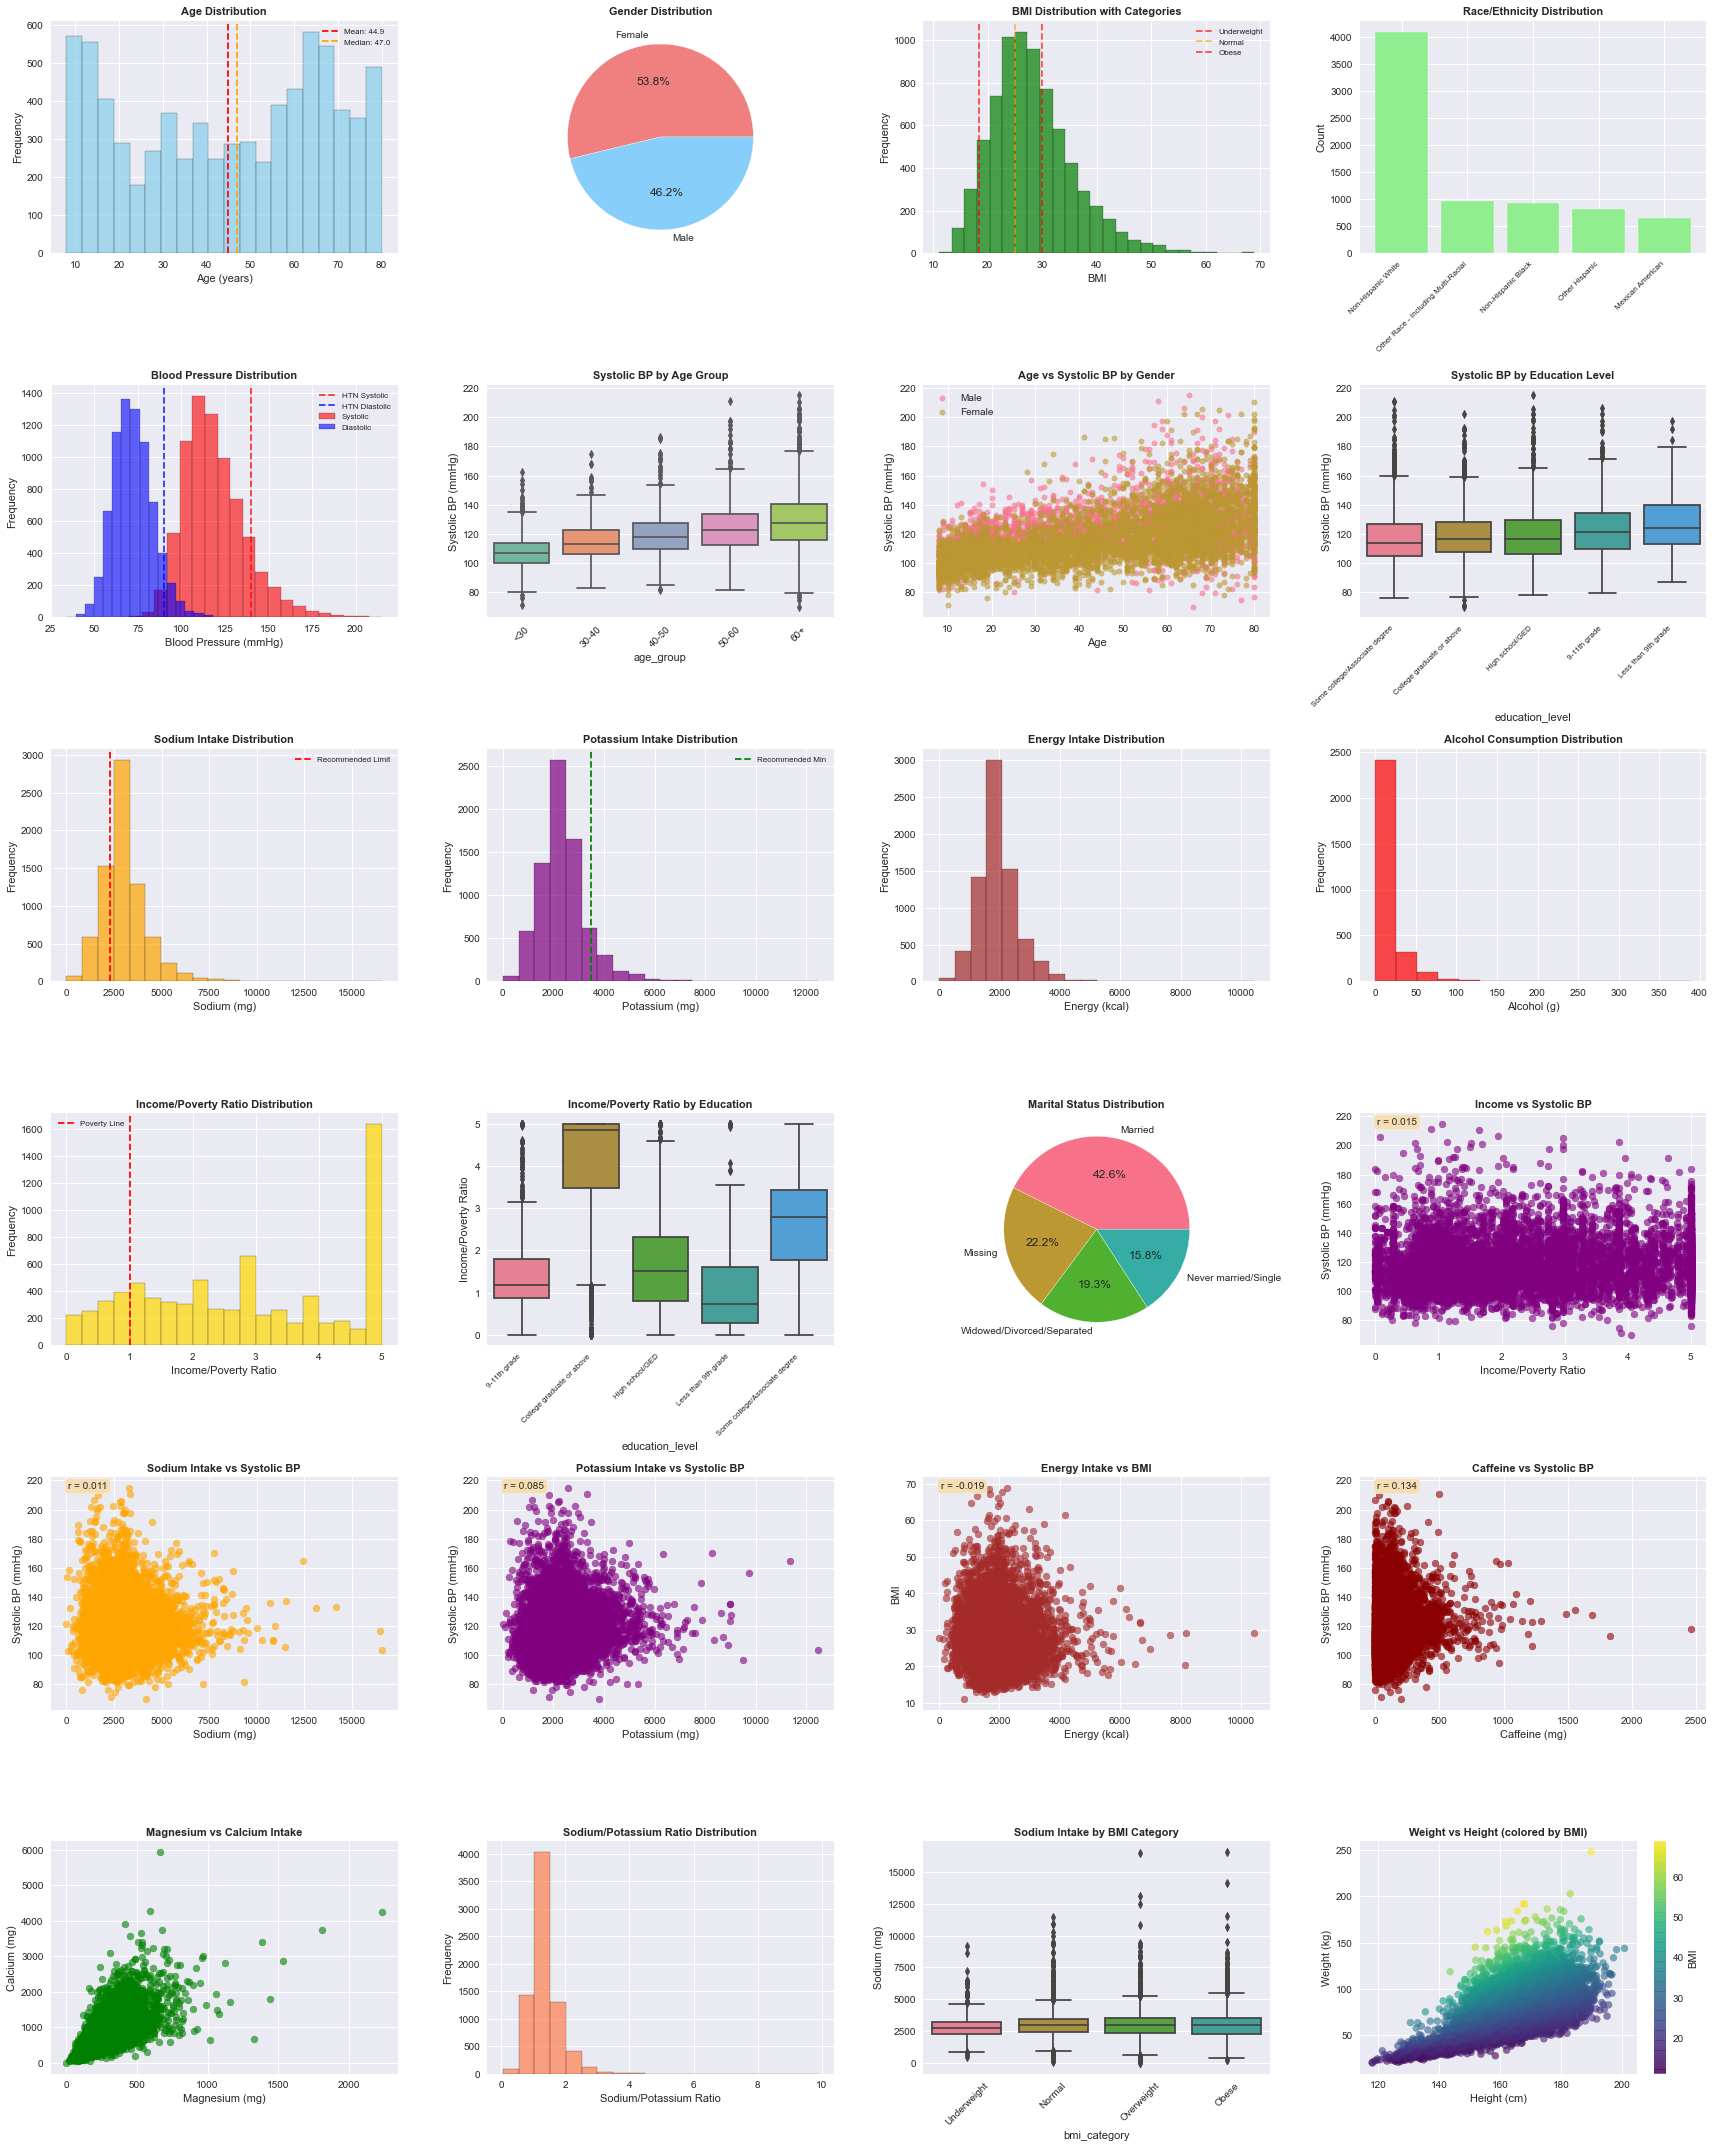


COMPREHENSIVE STATISTICAL SUMMARY

📊 DEMOGRAPHIC STATISTICS:
------------------------------
Sample size: 7453
Age: 44.9 ± 22.6 years (range: 8-80)
Gender distribution: {'Female': 53.76358513350329, 'Male': 46.23641486649671}
BMI: 28.3 ± 7.6 (range: 11.1-68.9)
BMI Categories: {'Obese': 34.53642828391252, 'Normal': 29.90741983094056, 'Overweight': 28.525426002951832, 'Underweight': 7.03072588219509}

🩸 BLOOD PRESSURE STATISTICS:
-----------------------------------
Systolic BP: 119.0 ± 18.1 mmHg
Diastolic BP: 72.2 ± 11.4 mmHg
Hypertension prevalence: 1094 participants (14.7%)

🥗 NUTRITIONAL INTAKE STATISTICS:
----------------------------------------
Sodium: 3071 ± 1224 mg
Potassium: 2399 ± 969 mg
Magnesium: 282 ± 121 mg
Calcium: 886 ± 419 mg
Energy: 1977 ± 710 kcal
Caffeine: 126.9 ± 137.4 mg
High sodium intake (>2300mg): 5712 participants (76.6%)
Alcohol consumption (consumers only): 15.5 ± 21.5 g
Alcohol consumers: 2885 (38.7%)

💰 SOCIOECONOMIC STATISTICS:
------------------------------

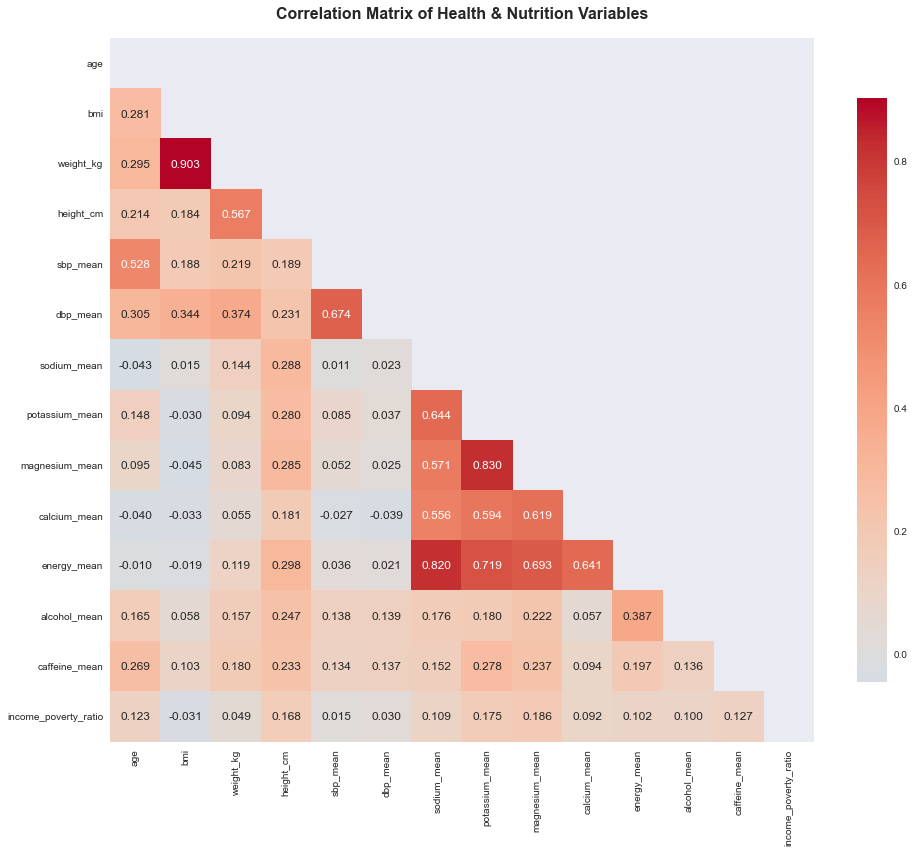


🔍 TOP CORRELATIONS WITH SYSTOLIC BLOOD PRESSURE:
↗️ dbp_mean: 0.674
↗️ age: 0.528
↗️ weight_kg: 0.219
↗️ height_cm: 0.189
↗️ bmi: 0.188
↗️ alcohol_mean: 0.138
↗️ caffeine_mean: 0.134
↗️ potassium_mean: 0.085
↗️ magnesium_mean: 0.052
↗️ energy_mean: 0.036
↘️ calcium_mean: -0.027
↗️ income_poverty_ratio: 0.015
↗️ sodium_mean: 0.011

🔍 TOP CORRELATIONS WITH BMI:
↗️ weight_kg: 0.903
↗️ dbp_mean: 0.344
↗️ age: 0.281
↗️ sbp_mean: 0.188
↗️ height_cm: 0.184
↗️ caffeine_mean: 0.103
↗️ alcohol_mean: 0.058
↘️ magnesium_mean: -0.045
↘️ calcium_mean: -0.033
↘️ income_poverty_ratio: -0.031
↘️ potassium_mean: -0.030
↘️ energy_mean: -0.019
↗️ sodium_mean: 0.015

STATISTICAL TESTS

🧪 GENDER DIFFERENCES IN BLOOD PRESSURE:
Male SBP: 121.1 ± 17.1 mmHg
Female SBP: 117.2 ± 18.7 mmHg
T-test: t = 9.252, p = 0.000
✅ Significant difference between genders

🧪 EDUCATION LEVEL DIFFERENCES IN INCOME:
ANOVA: F = 1094.506, p = 0.000
✅ Significant differences in income across education levels

🧪 ASSOCIATION BETWEEN G

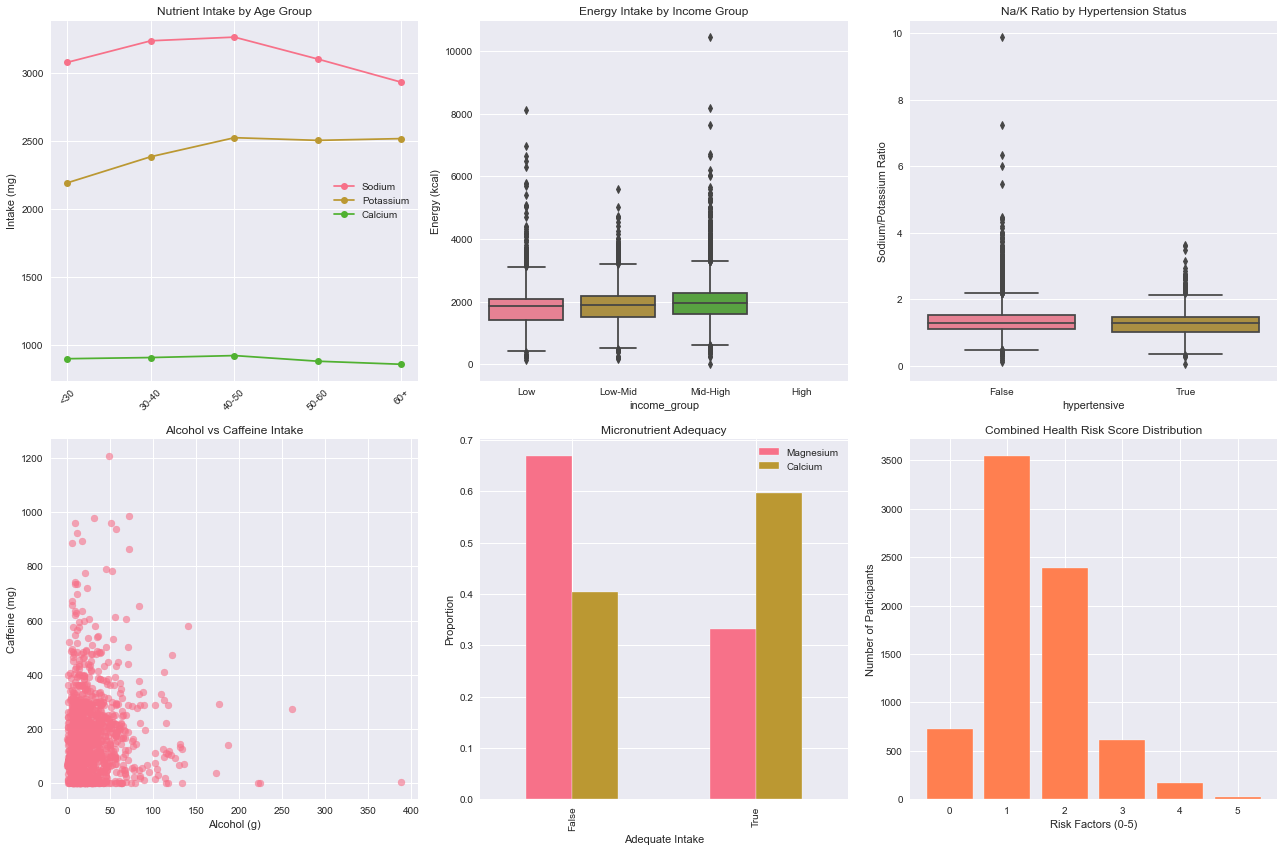


DIETARY PATTERN ANALYSIS

🍽️ DIETARY PATTERNS:
-------------------------
High Sodium + Low Potassium: 4960 participants (66.6%)
Adequate Potassium + Normal Sodium: 30 participants (0.4%)
High Energy + Regular Alcohol: 605 participants (8.1%)
High Caffeine + High Energy: 764 participants (10.3%)

🏥 HEALTH OUTCOMES BY DIETARY PATTERNS:
---------------------------------------------
High sodium group (n=5712):
  - Average SBP: 118.8 mmHg
  - Average BMI: 28.1
Normal sodium group (n=1741):
  - Average SBP: 119.7 mmHg
  - Average BMI: 28.8
  - T-test p-value: 0.088

KEY HEALTH INSIGHTS & RECOMMENDATIONS

🎯 CRITICAL FINDINGS:
-------------------------
1. Hypertension prevalence: 1094/7453 (14.7%)
2. Obesity prevalence: 2606/7453 (35.0%)
3. Excessive sodium intake: 5712/7453 (76.6%)
4. Inadequate potassium intake: 6671/7453 (89.5%)
5. Below poverty line: 1201/7453 (16.1%)

📈 STRONGEST CORRELATIONS WITH BLOOD PRESSURE:
--------------------------------------------------
1. Age: r=0.528***
   → 

,participant_id,bp_cuff_size,weight_kg,height_cm,bmi,age,gender,race_ethnicity,education_level,income_poverty_ratio,...,income_group,hypertensive,mg_adequate,ca_adequate,health_risk_score,high_sodium,adequate_potassium,high_energy,regular_alcohol,high_caffeine
0,130378.0,4.0,86.9,179.5,27.0,43.0,Male,Other Race - Including Multi-Racial,College graduate or above,5.00,...,Mid-High,True,False,False,1,False,False,False,True,False
1,130379.0,4.0,101.8,174.2,33.5,66.0,Male,Non-Hispanic White,College graduate or above,5.00,...,Mid-High,False,True,False,2,True,True,True,True,False
2,130380.0,4.0,69.4,152.9,29.7,44.0,Female,Other Hispanic,High school/GED,1.41,...,Low-Mid,False,True,True,1,True,False,False,False,False
3,130386.0,4.0,90.6,173.3,30.2,34.0,Male,Mexican American,Some college/Associate degree,1.33,...,Low-Mid,False,False,False,2,True,False,False,True,True
4,130387.0,4.0,103.5,155.9,42.6,68.0,Female,Non-Hispanic White,College graduate or above,1.32,...,Low-Mid,True,True,False,3,True,True,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7794,142304.0,2.0,48.9,162.4,18.5,14.0,Male,Other Hispanic,Some college/Associate degree,2.16,...,Mid-High,False,False,False,0,False,False,False,False,False
7795,142305.0,3.0,60.4,151.4,26.4,76.0,Female,Mexican American,Less than 9th grade,2.25,...,Mid-High,True,False,True,2,True,False,False,True,False
7798,142308.0,3.0,79.3,173.3,26.4,50.0,Male,Other Hispanic,Some college/Associate degree,1.95,...,Low-Mid,False,True,True,1,True,False,False,True,False
7799,142309.0,3.0,81.9,179.1,25.5,40.0,Male,Other Hispanic,Some college/Associate degree,3.11,...,Mid-High,False,False,True,1,True,False,True,False,False


In [359]:
run_comprehensive_health_analysis(df)

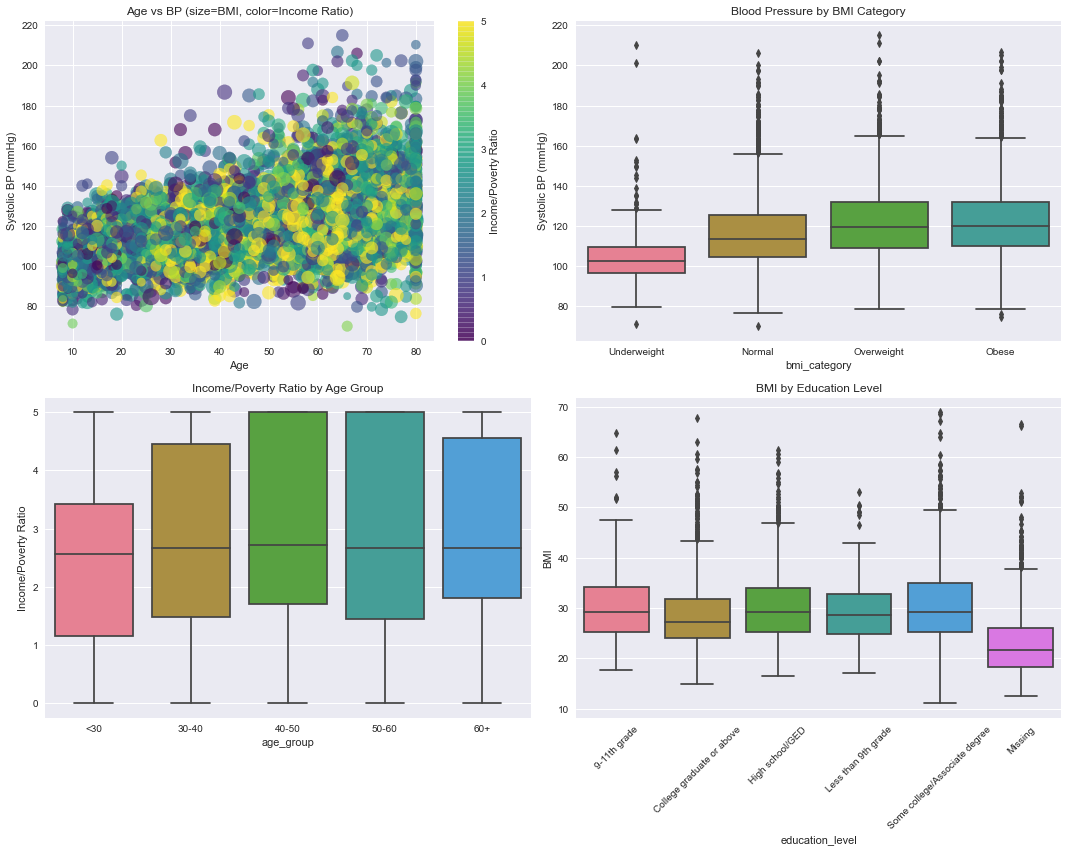

In [160]:
create_detailed_plots(df)

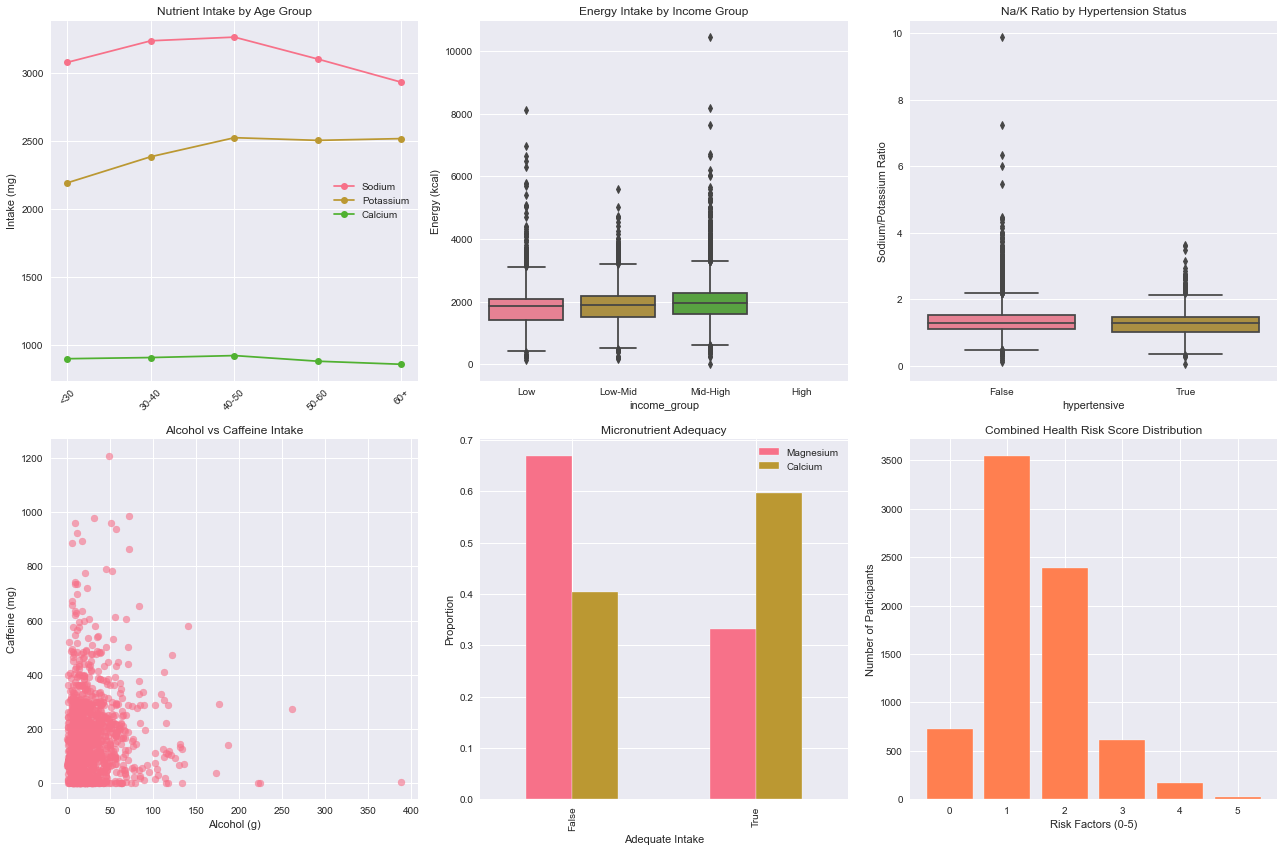

In [360]:
create_advanced_nutrition_plots(df)